# Anime Recommendation System 🎬
**Author:** Hedyeh Nayebi  
**Objective:** Building a robust recommendation engine using Collaborative Filtering.

### Table of Contents:
1. Data Loading & Setup
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Noise Reduction

In [1]:
# 1. Libraries & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
# 2. Data Loading
rating_df = pd.read_csv('/Users/plantpieck/UT/anime-recommender/data/rating.csv')
print(f"Dataset loaded successfully with {len(rating_df):,} rows.")

Dataset loaded successfully with 7,813,737 rows.


## 1. Exploratory Data Analysis (EDA)

The interaction dataset is modeled as a matrix $R \in \mathbb{R}^{U \times I}$, where $U$ denotes users, $I$ denotes anime titles, and $r_{ui}$ is the rating given by user $u$ to anime $i$.
The sparsity of this matrix is mathematically defined as:

$$Sparsity = 1 - \frac{|\{r_{ui} \mid r_{ui} \neq 0\}|}{|U| \times |I|}$$

Furthermore, the interaction frequency follows a power-law distribution, expressed as $P(x) \propto x^{-\alpha}$, which indicates a significant long-tail phenomenon.

Matrix Sparsity: 99.05%


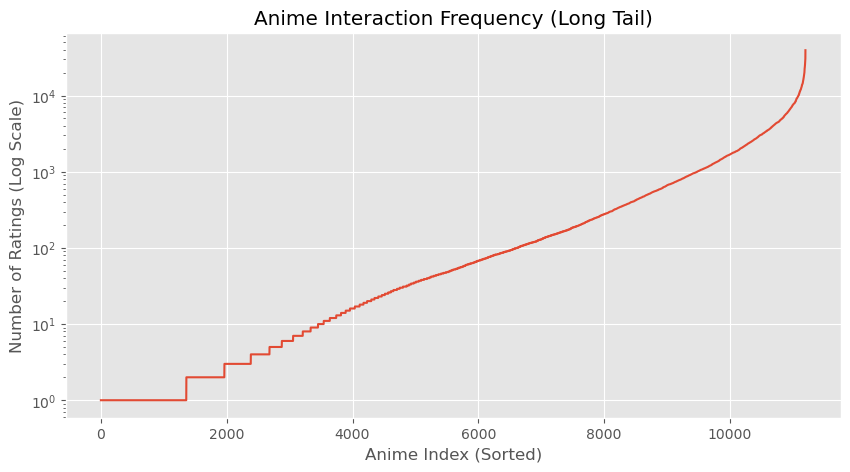

In [3]:
# Calculate dimensions and sparsity
num_users = rating_df['user_id'].nunique()
num_animes = rating_df['anime_id'].nunique()
total_ratings = len(rating_df)

density = total_ratings / (num_users * num_animes)
sparsity = 1 - density
print(f"Matrix Sparsity: {sparsity * 100:.2f}%")

# Plotting the Long Tail distribution
anime_popularity = rating_df.groupby('anime_id')['rating'].count()
plt.figure(figsize=(10, 5))
plt.plot(np.sort(anime_popularity.values))
plt.yscale('log')
plt.title('Anime Interaction Frequency (Long Tail)')
plt.ylabel('Number of Ratings (Log Scale)')
plt.xlabel('Anime Index (Sorted)')
plt.show()

## 2. Data Preprocessing & Noise Reduction

To address the cold-start problem and reduce computational complexity, we filter out inactive users. By setting a threshold, we ensure the model learns from reliable profiles with established preferences.

In [4]:
# Define threshold for active users
min_ratings = 50 

# Count ratings per user
user_counts = rating_df['user_id'].value_counts()

# Filter active users
active_users = user_counts[user_counts >= min_ratings].index
filtered_rating_df = rating_df[rating_df['user_id'].isin(active_users)]

# Display filtering impact
print(f"Original dataset size: {len(rating_df):,} ratings")
print(f"Filtered dataset size: {len(filtered_rating_df):,} ratings")
print(f"Number of active users retained: {len(active_users):,}")
print(f"Number of dropped users: {len(user_counts) - len(active_users):,}")

Original dataset size: 7,813,737 ratings
Filtered dataset size: 7,166,253 ratings
Number of active users retained: 39,466
Number of dropped users: 34,049


## 3. User-Item Matrix Construction

In this section, we transform the filtered longitudinal dataframe into a wide user-item interaction matrix $R \in \mathbb{R}^{U \times I}$. 
The rows represent unique users, columns represent unique anime titles, and the cells contain the corresponding ratings. Unobserved interactions (where a user has not rated an anime) are explicitly imputed with $0$ to represent a lack of interaction, which is essential for mathematical distance calculations.

In [8]:
# --- Day 3: User-Item Matrix Construction ---

# 1. Use pivot_table instead of pivot to handle duplicate ratings (takes the average)
# This will safely aggregate duplicate user-anime interactions
user_item_matrix = filtered_rating_df.pivot_table(index='user_id', 
                                                  columns='anime_id', 
                                                  values='rating', 
                                                  aggfunc='mean')

# 2. Fill missing values (NaN) with 0
user_item_matrix_filled = user_item_matrix.fillna(0)

# 3. Print the shape and verify
print("User-Item Matrix created successfully!")
print(f"Matrix Shape: {user_item_matrix_filled.shape[0]:,} users (rows) x {user_item_matrix_filled.shape[1]:,} animes (columns)")

User-Item Matrix created successfully!
Matrix Shape: 39,466 users (rows) x 11,197 animes (columns)


## 4. Similarity Computation (Item-Based Collaborative Filtering)

To generate recommendations, we need to quantify how similar two anime titles are based on user rating patterns. We employ **Cosine Similarity**, which measures the cosine of the angle between two non-zero vectors in a multi-dimensional space.

For two items $i$ and $j$, the similarity is calculated as:
$$sim(i, j) = \cos(\theta) = \frac{\mathbf{v}_i \cdot \mathbf{v}_j}{\|\mathbf{v}_i\| \|\mathbf{v}_j\|}$$

By focusing on Item-Based Collaborative Filtering (rather than User-Based), we benefit from a smaller and more computationally stable similarity matrix.

In [9]:
# --- Day 4: Similarity Computation ---
from sklearn.metrics.pairwise import cosine_similarity

# 1. Transpose the matrix
# We transpose so that animes become rows and users become columns (features)
item_user_matrix = user_item_matrix_filled.T

# 2. Calculate Cosine Similarity
# This creates an 11k x 11k dense matrix (might take a few seconds)
item_similarity = cosine_similarity(item_user_matrix)

# 3. Convert back to a DataFrame for easy lookups later
item_similarity_df = pd.DataFrame(item_similarity, 
                                  index=item_user_matrix.index, 
                                  columns=item_user_matrix.index)

print("Item Similarity Matrix calculated successfully!")
print(f"Similarity Matrix Shape: {item_similarity_df.shape[0]:,} x {item_similarity_df.shape[1]:,}")

Item Similarity Matrix calculated successfully!
Similarity Matrix Shape: 11,197 x 11,197


## 5. Recommendation Generation

With the item similarity matrix constructed, we can now implement the core recommendation logic. In this section, we create a function that takes a target anime ID as input, scans the similarity matrix, and retrieves the top $N$ most similar anime titles based on historical user voting patterns.

In [10]:
# --- Recommendation Function ---

def get_similar_animes(anime_id, top_n=5):
    """
    Returns the top N most similar animes for a given anime_id
    """
    if anime_id not in item_similarity_df.index:
        return f"Anime ID {anime_id} not found in the filtered matrix."
    
    # Get similarity scores for the target anime, sort them in descending order
    similar_scores = item_similarity_df[anime_id].sort_values(ascending=False)
    
    # Exclude the first item because it's the anime itself (similarity = 1.0)
    top_similar = similar_scores.iloc[1:top_n+1]
    
    return top_similar

# --- TEST THE SYSTEM ---
test_anime_id = 20  

print(f"Top {5} recommendations for Anime ID {test_anime_id}:")
print(get_similar_animes(test_anime_id, top_n=5))

Top 5 recommendations for Anime ID 20:
anime_id
1535     0.615486
11757    0.539170
121      0.538463
1575     0.535956
5114     0.535899
Name: 20, dtype: float64


## 6. Mapping IDs to Anime Titles

While the recommendation engine successfully identifies similar items based on vector distances, outputting raw `anime_id`s is not user-friendly. In this step, we integrate the secondary metadata dataset (`anime.csv`) to map the recommended IDs back to their human-readable anime titles.

In [13]:
import pandas as pd

anime_df = pd.read_csv('/Users/plantpieck/UT/anime-recommender/data/anime.csv')

# Create a Hash Map for O(1) lookups
anime_name_mapping = dict(zip(anime_df['anime_id'], anime_df['name']))

def get_full_recommendation(anime_id, top_n=5):
    if anime_id not in item_similarity_df.index:
        return f"Anime ID {anime_id} not found."
    
    target_name = anime_name_mapping.get(anime_id, "Unknown Anime")
    
    print(f"🎯 Because you watched [ {target_name} ]:")
    print("-" * 40)
    
    similar_scores = item_similarity_df[anime_id].sort_values(ascending=False)
    top_similar = similar_scores.iloc[1:top_n+1]
    
    results = []
    for sim_id, score in top_similar.items():
        name = anime_name_mapping.get(sim_id, "Unknown Anime")
        results.append({'name': name, 'similarity_score': score})
    
    return pd.DataFrame(results)

# Test the optimized system
get_full_recommendation(20, top_n=5)

🎯 Because you watched [ Naruto ]:
----------------------------------------


,name,similarity_score
0,Death Note,0.615486
1,Sword Art Online,0.539170
2,Fullmetal Alchemist,0.538463
3,Code Geass: Hangyaku no Lelouch,0.535956
4,Fullmetal Alchemist: Brotherhood,0.535899
